# StatsBomb Open Data — Menú interactivo (competición → partido → descarga → gráficas)

Este notebook:
1) Te deja elegir **competición/temporada** por nombre  
2) Te deja elegir **partido** por nombre (incluye `match_id`)  
3) Te deja elegir **qué descargar** (matches / events / lineups)  
4) Crea automáticamente una carpeta: `statsbomb_data/<home>_<away>_<match_id>/`  
5) Guarda datasets (CSV y/o Parquet) y genera **5 gráficas “pro”** para **local y visitante**, con opción de guardarlas.


In [1]:
# 0) Instalaciones (ejecuta una vez)
# %pip -q install pandas numpy requests pyarrow ipywidgets mplsoccer statsbombpy pillow


In [2]:
# 1) Imports y configuración
import os, re, ast, json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mplsoccer import Pitch

import ipywidgets as widgets
from IPython.display import display, clear_output

from statsbombpy import sb  # Open Data endpoints (statsbombpy)

# Ajustes generales de plots
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 11

OUTROOT = Path("statsbomb_data")
OUTROOT.mkdir(parents=True, exist_ok=True)

CACHE = {"competitions": None, "matches": {}, "events": {}, "lineups": {}}

def slug(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s

def ensure_list(v):
    if isinstance(v, (list, tuple)):
        return list(v)
    if isinstance(v, str) and v.startswith("[") and v.endswith("]"):
        try:
            vv = ast.literal_eval(v)
            if isinstance(vv, (list, tuple)):
                return list(vv)
        except Exception:
            return None
    return None

def split_xy(df: pd.DataFrame, col: str, xcol: str, ycol: str) -> pd.DataFrame:
    if col not in df.columns:
        if xcol not in df.columns: df[xcol] = np.nan
        if ycol not in df.columns: df[ycol] = np.nan
        return df
    v = df[col].apply(ensure_list)
    df[xcol] = v.apply(lambda z: z[0] if isinstance(z, list) and len(z) >= 2 else np.nan)
    df[ycol] = v.apply(lambda z: z[1] if isinstance(z, list) and len(z) >= 2 else np.nan)
    return df

def detect_team_col(ev: pd.DataFrame) -> str:
    for c in ["team", "team_name"]:
        if c in ev.columns:
            return c
    raise ValueError("No encuentro columna de equipo (team/team_name) en events.")

def detect_player_col(df: pd.DataFrame) -> str:
    for c in ["player", "player_name"]:
        if c in df.columns:
            return c
    raise ValueError("No encuentro columna de jugador (player/player_name).")

def detect_xg_col(shots: pd.DataFrame) -> str:
    for c in ["shot_statsbomb_xg", "shot_xg", "statsbomb_xg"]:
        if c in shots.columns:
            return c
    return ""

def detect_goal_mask(shots: pd.DataFrame) -> pd.Series:
    for c in ["shot_outcome", "shot_outcome_name"]:
        if c in shots.columns:
            s = shots[c].astype(str).str.lower()
            return s.str.contains("goal")
    if "outcome" in shots.columns:
        s = shots["outcome"].astype(str).str.lower()
        return s.str.contains("goal")
    return pd.Series(False, index=shots.index)

def open_play_completed_passes(passes: pd.DataFrame) -> pd.DataFrame:
    df = passes.copy()
    # completados
    if "pass_outcome" in df.columns:
        df = df[df["pass_outcome"].isna()].copy()
    # quitar ABP
    for c in ["pass_type", "pass_type_name"]:
        if c in df.columns:
            t = df[c].astype(str).str.lower()
            df = df[~t.isin(["corner", "free kick", "throw-in", "goal kick", "kick off"])].copy()
            break
    return df

def first_half_window(df: pd.DataFrame, max_min: int = 15) -> pd.DataFrame:
    out = df.copy()
    if "period" in out.columns:
        p = pd.to_numeric(out["period"], errors="coerce").fillna(1).astype(int)
        out = out[p == 1].copy()
    if "minute" in out.columns:
        m = pd.to_numeric(out["minute"], errors="coerce").fillna(0).astype(int)
        out = out[m <= max_min].copy()
    return out


In [3]:
# 2) Capa de datos (StatsBomb Open Data via statsbombpy)

def get_competitions() -> pd.DataFrame:
    if CACHE["competitions"] is None:
        df = sb.competitions()
        CACHE["competitions"] = df.copy()
    return CACHE["competitions"].copy()

def get_matches(competition_id: int, season_id: int) -> pd.DataFrame:
    key = (int(competition_id), int(season_id))
    if key not in CACHE["matches"]:
        df = sb.matches(competition_id=competition_id, season_id=season_id)
        CACHE["matches"][key] = df.copy()
    return CACHE["matches"][key].copy()

def get_events(match_id: int) -> pd.DataFrame:
    mid = int(match_id)
    if mid not in CACHE["events"]:
        df = sb.events(match_id=mid)
        CACHE["events"][mid] = df.copy()
    return CACHE["events"][mid].copy()

def get_lineups(match_id: int) -> pd.DataFrame:
    mid = int(match_id)
    if mid in CACHE["lineups"]:
        return CACHE["lineups"][mid].copy()

    df = sb.lineups(match_id=mid)

    # Caso A: ya viene como DataFrame
    if isinstance(df, pd.DataFrame):
        out = df.copy()
        CACHE["lineups"][mid] = out
        return out.copy()

    rows = []

    # Caso B: dict {team: [players...]} (lo más común)
    if isinstance(df, dict):
        # Si sus valores son listas, intentamos aplanar jugadores
        if any(isinstance(v, list) for v in df.values()):
            for team_name, players in df.items():
                if not isinstance(players, list):
                    continue
                for p in players:
                    row = {"team": team_name}
                    if isinstance(p, dict):
                        row.update(p)
                    else:
                        row["player"] = p
                    rows.append(row)
            out = pd.DataFrame(rows)
            CACHE["lineups"][mid] = out.copy()
            return out.copy()

        # Caso C: dict de escalares (evita el error "all scalar values")
        out = pd.DataFrame([df])
        CACHE["lineups"][mid] = out.copy()
        return out.copy()

    # Caso D: cualquier otra cosa (lista, etc.)
    if isinstance(df, list):
        out = pd.DataFrame(df)
        CACHE["lineups"][mid] = out.copy()
        return out.copy()

    # Fallback: una fila con la representación
    out = pd.DataFrame([{"raw": str(df)}])
    CACHE["lineups"][mid] = out.copy()
    return out.copy()


def match_context(matches_df: pd.DataFrame, match_id: int) -> dict:
    ctx = {"match_id": int(match_id), "home_team": None, "away_team": None,
           "home_score": None, "away_score": None, "match_date": None,
           "competition": None, "season": None}
    if matches_df is None or matches_df.empty:
        return ctx
    if "match_id" not in matches_df.columns:
        return ctx
    row = matches_df.loc[matches_df["match_id"] == int(match_id)]
    if row.empty:
        return ctx
    r = row.iloc[0]

    def pick(cols):
        for c in cols:
            if c in matches_df.columns:
                return r.get(c)
        return None

    ctx["home_team"] = pick(["home_team_name", "home_team"])
    ctx["away_team"] = pick(["away_team_name", "away_team"])
    ctx["home_score"] = pick(["home_score"])
    ctx["away_score"] = pick(["away_score"])
    ctx["match_date"] = pick(["match_date", "date", "kick_off"])
    ctx["competition"] = pick(["competition_name", "competition"])
    ctx["season"] = pick(["season_name", "season"])
    return ctx

def fmt_ctx(ctx: dict) -> str:
    ht = ctx.get("home_team") or "Home"
    at = ctx.get("away_team") or "Away"
    hs, a_s = ctx.get("home_score"), ctx.get("away_score")
    score = f"{hs}-{a_s}" if (hs is not None and a_s is not None) else ""
    meta = " | ".join([str(x) for x in [ctx.get("competition"), ctx.get("season"), ctx.get("match_date")] if x not in [None, "nan", "NaT"] and str(x).strip()])
    head = f"{ht} vs {at}"
    if score:
        head += f" ({score})"
    if meta:
        head += f" — {meta}"
    return head

def match_outdir(ctx: dict) -> Path:
    ht = slug(ctx.get("home_team") or "home")
    at = slug(ctx.get("away_team") or "away")
    mid = int(ctx.get("match_id") or 0)
    d = OUTROOT / f"{ht}_{at}_{mid}"
    d.mkdir(parents=True, exist_ok=True)
    return d

def save_df(df: pd.DataFrame, outdir: Path, stem: str, save_csv=True, save_parquet=True):
    """
    Guarda DataFrames a CSV y/o Parquet de forma robusta.
    StatsBomb (especialmente lineups) puede traer columnas con objetos complejos
    (listas/dicts/Series/DataFrames). Para Parquet (pyarrow) convertimos esos objetos
    a JSON string de forma segura.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    out = {}

    def _to_jsonable(x):
        # Convierte a algo serializable (dict/list/str/None/number)
        if isinstance(x, (dict, list)):
            return x
        if isinstance(x, pd.DataFrame):
            return x.to_dict(orient="records")
        if isinstance(x, pd.Series):
            return x.to_list()
        # numpy types
        if hasattr(x, "item") and callable(getattr(x, "item")):
            try:
                return x.item()
            except Exception:
                pass
        return x

    def _safe_json_str(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        try:
            return json.dumps(_to_jsonable(x), ensure_ascii=False, default=str)
        except Exception:
            return str(x)

    if save_parquet:
        pq = outdir / f"{stem}.parquet"
        df2 = df.copy()

        # pyarrow falla con dtype object + valores no escalares.
        for c in df2.columns:
            if df2[c].dtype == "object":
                # si hay cualquier valor "complejo", serializa toda la columna
                complex_mask = df2[c].apply(lambda v: isinstance(v, (dict, list, pd.DataFrame, pd.Series)))
                if complex_mask.any():
                    df2[c] = df2[c].apply(_safe_json_str)

        df2.to_parquet(pq, index=False)
        out["parquet"] = pq

    if save_csv:
        csv = outdir / f"{stem}.csv"
        df.to_csv(csv, index=False, encoding="utf-8")
        out["csv"] = csv

    return out


In [4]:
from typing import Optional
import numpy as np

# 3) Gráficas “pro” (Top 5) — local y visitante
# Nota: estandarizamos para que ambos equipos “ataquen a la derecha”
# (se espeja el visitante), para comparar mejor.

PITCH_L = 120
PITCH_W = 80

def prep_events_for_plots(events_df: pd.DataFrame) -> pd.DataFrame:
    ev = events_df.copy()
    ev = split_xy(ev, "location", "x", "y")
    ev = split_xy(ev, "pass_end_location", "pass_end_x", "pass_end_y")
    return ev

def mirror_coords(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for a,b in [("x","y"), ("pass_end_x","pass_end_y")]:
        if a in out.columns:
            out[a] = PITCH_L - pd.to_numeric(out[a], errors="coerce")
        if b in out.columns:
            out[b] = PITCH_W - pd.to_numeric(out[b], errors="coerce")
    return out

def normalize_attack_right(df: pd.DataFrame, team: str, ctx: dict) -> pd.DataFrame:
    away = str(ctx.get("away_team") or "")
    if away and str(team) == away:
        return mirror_coords(df)
    return df

def plot_shot_map(events_xy: pd.DataFrame, ctx: dict, save=False, outdir: Optional[Path] = None):
    """
    Shot map (ambos equipos) con:
    - Tamaño ~ xG
    - Estrella = gol
    - Disparos con/ sin gol diferenciados por marcador (círculo vs estrella)
    - Orientación consistente: ambos equipos atacan hacia la derecha (visitante espejado)
    """
    team_col = detect_team_col(events_xy)
    shots = events_xy[events_xy["type"] == "Shot"].copy()
    if shots.empty:
        return

    xg_col = detect_xg_col(shots)
    if not xg_col:
        shots["xg"] = 0.0
        xg_col = "xg"
    shots[xg_col] = pd.to_numeric(shots[xg_col], errors="coerce").fillna(0.0).clip(0, 1)

    # contexto
    teams = [ctx.get("home_team"), ctx.get("away_team")]
    teams = [t for t in teams if t is not None]

    # Colores por equipo (relleno). Si no coincide, usa gris.
    colors = {}
    if len(teams) >= 1:
        colors[str(teams[0])] = "#1f77b4"
    if len(teams) >= 2:
        colors[str(teams[1])] = "#ff7f0e"

    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(11.5, 7.2))

    # Nota: evitamos colores explícitos; usamos estilos (edge/alpha) y labels.
    legend_handles = []
    legend_labels = []

    for t in teams:
        team_color = colors.get(str(t), "#808080")
        s = shots[shots[team_col] == t].dropna(subset=["x", "y"]).copy()
        if s.empty:
            continue
        s = normalize_attack_right(s, team=t, ctx=ctx)

        # Tamaño en función del xG (más legible que lineal puro)
        sizes = 35 + (s[xg_col] ** 0.55) * 950

        goals = detect_goal_mask(s)
        nong = s[~goals]
        g = s[goals]

        # No-gol: círculos con borde
        sc = pitch.scatter(
            nong["x"], nong["y"],
            s=sizes.loc[nong.index],
            ax=ax, alpha=0.75, linewidth=1.2,
            edgecolor="black", facecolor=team_color,
            label=str(t),
            zorder=3
        )

        # Gol: estrella sólida encima
        if not g.empty:
            pitch.scatter(
                g["x"], g["y"],
                s=240,
                marker="*",
                ax=ax,
                alpha=0.95,
                edgecolor="black",
                linewidth=0.8,
                zorder=4
            )

        legend_handles.append(sc)
        legend_labels.append(f"{t} (xG={s[xg_col].sum():.2f}, tiros={len(s)})")

    # Leyenda xG (tamaños de referencia)
    ref_xg = [0.05, 0.15, 0.30, 0.50]
    ref_sizes = 35 + (np.array(ref_xg) ** 0.55) * 950
    for xg, ss in zip(ref_xg, ref_sizes):
        ax.scatter([], [], s=ss, facecolors="none", edgecolors="black", linewidths=1.2, label=f"xG {xg:.2f}")
    ax.legend(loc="upper right", frameon=True)

    ax.set_title(f"Mapa de tiros (tamaño ~ xG, ★ = gol) — {fmt_ctx(ctx)}", pad=14)

    # Pie de figura: recordatorio de orientación
    ax.text(2, 78.5, "Orientación: ambos equipos atacan →", ha="left", va="top", fontsize=9, alpha=0.75)

    fig.tight_layout()
    if save and outdir is not None:
        (Path(outdir) / "01_shot_map.png").parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(Path(outdir) / "01_shot_map.png", bbox_inches="tight", dpi=180)
    plt.show()


def plot_xg_flow(events_xy: pd.DataFrame, ctx: dict, save=False, outdir: Optional[Path] = None):
    """
    xG acumulado por minuto (step chart) con:
    - Línea para cada equipo
    - Marcadores de gol sobre la curva (si se puede detectar)
    - Halftime / Fulltime como referencia
    """
    team_col = detect_team_col(events_xy)
    shots = events_xy[events_xy["type"] == "Shot"].copy()
    if shots.empty:
        return

    xg_col = detect_xg_col(shots)
    if not xg_col:
        shots["xg"] = 0.0
        xg_col = "xg"

    # tiempo (min + seg) para ordenamiento más fino
    shots["minute"] = pd.to_numeric(shots.get("minute", 0), errors="coerce").fillna(0).astype(int)
    shots["second"] = pd.to_numeric(shots.get("second", 0), errors="coerce").fillna(0).astype(int)
    shots["t"] = shots["minute"] + shots["second"] / 60.0

    shots["xg"] = pd.to_numeric(shots[xg_col], errors="coerce").fillna(0.0).clip(0, 1)

    teams = [ctx.get("home_team"), ctx.get("away_team")]
    teams = [t for t in teams if t is not None]

    # Colores por equipo (relleno). Si no coincide, usa gris.
    colors = {}
    if len(teams) >= 1:
        colors[str(teams[0])] = "#1f77b4"
    if len(teams) >= 2:
        colors[str(teams[1])] = "#ff7f0e"

    fig, ax = plt.subplots(figsize=(11.5, 5.8))

    # ejes consistentes
    ax.set_xlim(0, max(95, float(shots["t"].max() + 1)))

    for t in teams:
        team_color = colors.get(str(t), "#808080")
        s = shots[shots[team_col] == t].sort_values("t").copy()
        if s.empty:
            continue
        y = s["xg"].cumsum()
        ax.step(s["t"], y, where="post", linewidth=2.2, label=str(t))

        # marcar goles (si se detecta)
        goals = detect_goal_mask(s)
        if goals.any():
            sg = s[goals].copy()
            yg = y.loc[sg.index]
            ax.scatter(sg["t"], yg, marker="*", s=120, edgecolor="black", linewidth=0.7, zorder=5)

    # referencias
    ax.axvline(45, linestyle="--", linewidth=1, alpha=0.35)
    ax.axvline(90, linestyle="--", linewidth=1, alpha=0.35)

    # títulos y estilo
    ax.set_title(f"xG acumulado (por minuto) — {fmt_ctx(ctx)}", pad=12)
    ax.set_xlabel("Minuto")
    ax.set_ylabel("xG acumulado")
    ax.grid(True, alpha=0.22)
    ax.legend(frameon=True, loc="upper left")

    # anotaciones
    ymax = max(ax.get_ylim()[1], 0.01)
    ax.text(45, ymax*0.98, "HT", ha="right", va="top", fontsize=9, alpha=0.75)
    ax.text(90, ymax*0.98, "FT", ha="right", va="top", fontsize=9, alpha=0.75)
    ax.text(0.99, 0.02, "★ = gol", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, alpha=0.75)

    fig.tight_layout()
    if save and outdir is not None:
        fig.savefig(Path(outdir) / "02_xg_flow.png", bbox_inches="tight", dpi=180)
    plt.show()


def plot_passing_network(events_xy: pd.DataFrame, team: str, ctx: dict, save=False, outdir: Optional[Path] = None):
    """
    Passing network (Open Play, pases completados) en ventana 0–45' del 1T:
    - Nodo: posición media de origen del pase por jugador
    - Tamaño: volumen de pases (origen)
    - Aristas: pases completados entre jugador→receptor (filtra ruido)
    """
    team_col = detect_team_col(events_xy)
    player_col = detect_player_col(events_xy)

    passes = events_xy[events_xy["type"] == "Pass"].copy()
    if passes.empty:
        return
    passes = open_play_completed_passes(passes)
    passes = first_half_window(passes, max_min=45)

    # Columnas de receptor (dependen del endpoint / versión)
    rec_col = None
    for cand in ["pass_recipient", "pass_recipient_name"]:
        if cand in passes.columns:
            rec_col = cand
            break
    if rec_col is None:
        return

    p = passes[passes[team_col] == team].dropna(subset=["x", "y"]).copy()
    if p.empty:
        return
    p = normalize_attack_right(p, team=team, ctx=ctx)

    # Normalizar nombres si vienen como dicts
    def _name(v):
        if isinstance(v, dict):
            return v.get("name")
        return v

    p[player_col] = p[player_col].apply(_name)
    p[rec_col] = p[rec_col].apply(_name)

    p = p.dropna(subset=[player_col, rec_col]).copy()

    # Posición media de origen por jugador
    pos = (p.groupby(player_col)
             .agg(x_mean=("x", "mean"),
                  y_mean=("y", "mean"),
                  n=("x", "size"))
             .reset_index())

    # Conexiones jugador→receptor
    links = (p.groupby([player_col, rec_col])
               .size()
               .reset_index(name="count"))

    # Filtrar ruido: conexiones mínimas y jugadores con poco volumen
    links = links[links["count"] >= 2].copy()
    if links.empty:
        return
    keep_players = set(pos[pos["n"] >= 8][player_col])
    links = links[links[player_col].isin(keep_players) & links[rec_col].isin(keep_players)].copy()
    if links.empty:
        return

    # Merge posiciones de origen y receptor
    pos_map = pos.set_index(player_col)[["x_mean", "y_mean", "n"]].to_dict("index")
    links["sx"] = links[player_col].map(lambda k: pos_map.get(k, {}).get("x_mean"))
    links["sy"] = links[player_col].map(lambda k: pos_map.get(k, {}).get("y_mean"))
    links["ex"] = links[rec_col].map(lambda k: pos_map.get(k, {}).get("x_mean"))
    links["ey"] = links[rec_col].map(lambda k: pos_map.get(k, {}).get("y_mean"))
    links = links.dropna(subset=["sx", "sy", "ex", "ey"]).copy()

    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(11.5, 7.2))

    # Aristas: grosor ~ count (escalado)
    maxc = max(links["count"].max(), 1)
    widths = 0.6 + (links["count"] / maxc) * 4.0
    widths = widths.to_numpy()
    pitch.lines(links["sx"], links["sy"], links["ex"], links["ey"],
                lw=widths, ax=ax, alpha=0.35, zorder=2)

    # Nodos: tamaño ~ n
    maxn = max(pos["n"].max(), 1)
    node_sizes = 120 + (pos["n"] / maxn) * 900
    pitch.scatter(pos["x_mean"], pos["y_mean"],
                  s=node_sizes, ax=ax,
                  alpha=0.95, edgecolors="black", linewidth=0.4, zorder=3)

    # Etiquetas (apellido)
    for _, r in pos.iterrows():
        lab = str(r[player_col]).split()[-1]
        ax.text(r["x_mean"], r["y_mean"], lab, ha="center", va="center", fontsize=8, zorder=4)

    # Títulos / subtítulos
    ax.set_title(f"Passing network — {team} — {fmt_ctx(ctx)}", pad=14)
    ax.text(0.01, 0.01, "Filtros: Open Play + completados | Ventana: 1T 0–45' | Jugadores ≥8 pases | Enlaces ≥2",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=9, alpha=0.75)

    fig.tight_layout()
    if save and outdir is not None:
        fig.savefig(Path(outdir) / f"03_passing_network_{slug(team)}.png", bbox_inches="tight", dpi=180)
    plt.show()


def plot_progressive_passes(events_xy: pd.DataFrame, team: str, ctx: dict, save=False, outdir: Optional[Path] = None):
    """
    Progressive passes (Open Play, completados):
    - Progreso medido como reducción de distancia al centro de la portería rival.
    - Se muestran los TOP N por progreso para legibilidad.
    """
    team_col = detect_team_col(events_xy)

    passes = events_xy[events_xy["type"] == "Pass"].copy()
    if passes.empty:
        return
    passes = open_play_completed_passes(passes)
    passes = passes.dropna(subset=["x", "y", "pass_end_x", "pass_end_y"]).copy()

    p = passes[passes[team_col] == team].copy()
    if p.empty:
        return
    p = normalize_attack_right(p, team=team, ctx=ctx)

    # Distancia a centro de portería rival (x=120, y=40)
    p["start_d"] = np.sqrt((PITCH_L - p["x"])**2 + (40 - p["y"])**2)
    p["end_d"] = np.sqrt((PITCH_L - p["pass_end_x"])**2 + (40 - p["pass_end_y"])**2)
    p["progress"] = p["start_d"] - p["end_d"]

    # Umbral de progresión (metros). 10m suele ser buen baseline.
    prog = p[p["progress"] >= 10].copy()
    if prog.empty:
        return

    # Top por progreso (evita saturar)
    prog = prog.sort_values("progress", ascending=False).head(35).copy()

    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(11.5, 7.2))

    # Grosor ~ progreso (escalado)
    maxp = max(float(prog["progress"].max()), 1.0)
    widths = 0.8 + (prog["progress"] / maxp) * 2.6
    widths = widths.to_numpy()
    # Nota: matplotlib.quiver (usado internamente por mplsoccer) no soporta `width` vectorial.
    # Dibujamos flechas en un loop para permitir grosor variable por pase.
    for (sx, sy, ex, ey, w) in zip(
        prog["x"].to_numpy(), prog["y"].to_numpy(),
        prog["pass_end_x"].to_numpy(), prog["pass_end_y"].to_numpy(),
        widths
    ):
        pitch.arrows(
            float(sx), float(sy), float(ex), float(ey),
            ax=ax, width=float(w),
            headwidth=5, headlength=5,
            alpha=0.35, zorder=3
        )

    # Resumen
    ax.set_title(f"Progressive passes (Open Play, completados) — {team} — {fmt_ctx(ctx)}", pad=14)
    ax.text(0.01, 0.01,
            f"Mostrando: top {len(prog)} | Umbral: ≥10m | Progreso total: {prog['progress'].sum():.0f}m",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=9, alpha=0.75)

    fig.tight_layout()
    if save and outdir is not None:
        fig.savefig(Path(outdir) / f"04_progressive_passes_{slug(team)}.png", bbox_inches="tight", dpi=180)
    plt.show()


def plot_pressure_heatmap(events_xy: pd.DataFrame, team: str, ctx: dict, save=False, outdir: Optional[Path] = None):
    """
    Pressure heatmap (ubicación de presiones):
    - KDE suavizado para patrón espacial más interpretable (menos cuadriculado).
    - Incluye conteo total en subtítulo.
    """
    team_col = detect_team_col(events_xy)
    press = events_xy[events_xy["type"] == "Pressure"].dropna(subset=["x", "y"]).copy()
    press = press[press[team_col] == team].copy()
    if press.empty:
        return
    press = normalize_attack_right(press, team=team, ctx=ctx)

    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(11.5, 7.2))

    # KDE (si falla por alguna razón, fallback a bins)
    try:
        kde = pitch.kdeplot(press["x"].to_numpy(), press["y"].to_numpy(), ax=ax, fill=True, levels=60, alpha=0.9, zorder=1)
        cbar = plt.colorbar(kde, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Densidad de presiones")
    except Exception:
        bin_stat = pitch.bin_statistic(press["x"], press["y"], statistic="count", bins=(24, 16))
        hm = pitch.heatmap(bin_stat, ax=ax, alpha=0.85)
        cbar = plt.colorbar(hm, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Conteo de presiones")

    ax.set_title(f"Presiones — mapa de calor — {team} — {fmt_ctx(ctx)}", pad=14)
    ax.text(0.01, 0.01, f"Total presiones: {len(press)} | Orientación: ambos equipos atacan →",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=9, alpha=0.75)

    fig.tight_layout()
    if save and outdir is not None:
        fig.savefig(Path(outdir) / f"05_pressure_heatmap_{slug(team)}.png", bbox_inches="tight", dpi=180)
    plt.show()



# ------------------------------------------------------------
# Match report (presentación): muestra todas las gráficas en una sola vista (grid 4x4)
# Nota: NO altera la lógica de cálculo de las gráficas; sólo compone una vista a partir de los PNG guardados.
# ------------------------------------------------------------
import numpy as np
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

def _autocrop_white_arr(arr: np.ndarray, tol: int = 8, pad: int = 6) -> np.ndarray:
    """Recorta márgenes casi blancos de una imagen (numpy array)."""
    a = arr
    if a.ndim == 2:  # gray
        a = np.stack([a, a, a], axis=-1)
    if a.shape[-1] == 4:
        rgb = a[..., :3]
        alpha = a[..., 3]
    else:
        rgb = a[..., :3]
        alpha = None

    # normaliza a uint8 0-255
    if rgb.dtype != np.uint8:
        rgb_u = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
    else:
        rgb_u = rgb

    white = (rgb_u[..., 0] >= 255 - tol) & (rgb_u[..., 1] >= 255 - tol) & (rgb_u[..., 2] >= 255 - tol)
    if alpha is not None:
        if alpha.dtype != np.uint8:
            a_u = np.clip(alpha * 255.0, 0, 255).astype(np.uint8)
        else:
            a_u = alpha
        white = white | (a_u == 0)

    nonwhite = ~white
    if not np.any(nonwhite):
        return arr

    ys, xs = np.where(nonwhite)
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])
    return arr[y0:y1, x0:x1]

def show_match_report(outdir: Path, ctx: dict, teams: list[str]) -> None:
    """
    Renderiza un 'match report' en una cuadrícula 4x4 (paneles 2 columnas) con las 8 gráficas guardadas.
    - NO regenera gráficas: solo carga los PNG creados por las funciones existentes.
    - Orden para comparación: (Home | Away) lado a lado en redes/pases progresivos/presiones.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from matplotlib.gridspec import GridSpec

    outdir = Path(outdir)

    def p(name: str) -> Path:
        return outdir / name

    def _read_and_crop(path: Path):
        """Lee PNG y recorta márgenes blancos para aprovechar el espacio (solo para presentación)."""
        if not path.exists():
            return None
        img = mpimg.imread(str(path))
        # Normaliza a RGB para el cálculo de "blanco"
        if img.ndim == 2:
            rgb = np.stack([img, img, img], axis=-1)
        elif img.shape[-1] == 4:
            rgb = img[..., :3]
        else:
            rgb = img[..., :3]

        # Máscara de píxeles "no-blancos"
        # Umbral alto para detectar bordes muy claros sin comerse elementos finos
        thresh = 0.985
        nonwhite = np.any(rgb < thresh, axis=-1)
        if not np.any(nonwhite):
            return img

        ys, xs = np.where(nonwhite)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()

        # Margen de seguridad (evita recortar títulos/labels)
        pad_y = max(6, int(0.01 * (y1 - y0 + 1)))
        pad_x = max(6, int(0.01 * (x1 - x0 + 1)))

        y0 = max(0, y0 - pad_y)
        y1 = min(img.shape[0] - 1, y1 + pad_y)
        x0 = max(0, x0 - pad_x)
        x1 = min(img.shape[1] - 1, x1 + pad_x)

        return img[y0:y1 + 1, x0:x1 + 1, ...] if img.ndim == 3 else img[y0:y1 + 1, x0:x1 + 1]

    # Nombres de equipos (para títulos)
    home = teams[0] if len(teams) >= 1 else "Local"
    away = teams[1] if len(teams) >= 2 else "Visitante"

    # Paths esperados (no cambiamos naming de guardado: solo los consumimos)
    files = {
        "shot_map": p("01_shot_map.png"),
        "xg_flow": p("02_xg_flow.png"),
        "pn_home": p(f"03_passing_network_{str(home).lower().replace(' ', '_')}.png"),
        "pn_away": p(f"03_passing_network_{str(away).lower().replace(' ', '_')}.png"),
        "pp_home": p(f"04_progressive_passes_{str(home).lower().replace(' ', '_')}.png"),
        "pp_away": p(f"04_progressive_passes_{str(away).lower().replace(' ', '_')}.png"),
        "pr_home": p(f"05_pressure_heatmap_{str(home).lower().replace(' ', '_')}.png"),
        "pr_away": p(f"05_pressure_heatmap_{str(away).lower().replace(' ', '_')}.png"),
    }

    # Carga + crop (solo presentación)
    imgs = {k: _read_and_crop(v) for k, v in files.items()}

    # Si faltan pares (por ejemplo si solo hay 1 equipo), degradamos de forma segura
    def _title_from_ctx():
        comp = ctx.get("competition_name", "") or ctx.get("competition", "")
        season = ctx.get("season_name", "") or ctx.get("season", "")
        date = ctx.get("match_date", "") or ctx.get("date", "")
        score = ctx.get("scoreline", "") or ""
        left = f"{home} vs {away}".strip()
        mid = " | ".join([s for s in [comp, season] if s])
        right = " | ".join([s for s in [date, score] if s])
        parts = [left]
        if mid:
            parts.append(mid)
        if right:
            parts.append(right)
        return " — ".join(parts)

    # Figura: formato más ancho para evitar "cargado a la derecha"
    fig = plt.figure(figsize=(18, 20), dpi=120)
    gs = GridSpec(
        4, 4, figure=fig,
        left=0.03, right=0.97, top=0.93, bottom=0.03,
        wspace=0.06, hspace=0.10
    )

    # Panel helper: cada gráfico ocupa 2 columnas (para 4x4)
    def _ax(r, c0):
        ax = fig.add_subplot(gs[r, c0:c0 + 2])
        ax.axis("off")
        return ax

    # Coloca imágenes (con fallback a texto si falta)
    def _place(ax, img, label=None):
        if img is None:
            ax.text(0.5, 0.5, "Imagen no disponible", ha="center", va="center", fontsize=12, color="#555")
            if label:
                ax.set_title(label, fontsize=12, pad=6)
            return
        ax.imshow(img, aspect="auto")
        if label:
            ax.set_title(label, fontsize=12, pad=6)

    # Row 1
    _place(_ax(0, 0), imgs["shot_map"], "Mapa de tiros")
    _place(_ax(0, 2), imgs["xg_flow"], "xG acumulado")

    # Row 2 (pares lado a lado)
    _place(_ax(1, 0), imgs["pn_home"], f"Passing network — {home}")
    _place(_ax(1, 2), imgs["pn_away"], f"Passing network — {away}")

    # Row 3
    _place(_ax(2, 0), imgs["pp_home"], f"Pases progresivos — {home}")
    _place(_ax(2, 2), imgs["pp_away"], f"Pases progresivos — {away}")

    # Row 4
    _place(_ax(3, 0), imgs["pr_home"], f"Presiones — {home}")
    _place(_ax(3, 2), imgs["pr_away"], f"Presiones — {away}")

    # Título general
    fig.suptitle(_title_from_ctx(), fontsize=16, fontweight="bold")

    plt.show()

def generate_top5(events_df: pd.DataFrame, matches_df: pd.DataFrame, match_id: int, save_figs: bool, outdir: Path):
    ctx = match_context(matches_df, match_id)
    teams = [ctx.get("home_team"), ctx.get("away_team")]
    teams = [t for t in teams if t is not None]

    # Colores por equipo (relleno). Si no coincide, usa gris.
    colors = {}
    if len(teams) >= 1:
        colors[str(teams[0])] = "#1f77b4"
    if len(teams) >= 2:
        colors[str(teams[1])] = "#ff7f0e"

    ev = prep_events_for_plots(events_df)

    plot_shot_map(ev, ctx, save=save_figs, outdir=outdir)
    plot_xg_flow(ev, ctx, save=save_figs, outdir=outdir)

    for t in teams:
        team_color = colors.get(str(t), "#808080")
        plot_passing_network(ev, t, ctx, save=save_figs, outdir=outdir)
        plot_progressive_passes(ev, t, ctx, save=save_figs, outdir=outdir)
        plot_pressure_heatmap(ev, t, ctx, save=save_figs, outdir=outdir)

    # Presentación: match report en una sola vista (requiere PNGs guardados)
    if save_figs and outdir is not None:
        show_match_report(outdir, ctx, teams)



# ==============================
# Match report (solo presentación)
# ==============================
def show_match_report(outdir: Path, ctx: dict, teams: list[str]) -> None:
    """
    Renderiza un 'match report' profesional en una cuadrícula 4x4 (paneles 2 columnas) con 8 PNGs:
      - 01_shot_map.png
      - 02_xg_flow.png
      - 03_passing_network_<home>.png / 03_passing_network_<away>.png
      - 04_progressive_passes_<home>.png / 04_progressive_passes_<away>.png
      - 05_pressure_heatmap_<home>.png / 05_pressure_heatmap_<away>.png

    Importante:
      - NO regenera gráficas: solo carga los PNG existentes.
      - NO modifica lógica ni menú: es solo una vista/maquetación.
      - Además de mostrarse, guarda el dashboard como PNG en la carpeta del partido.
    """
    import re
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from matplotlib.gridspec import GridSpec

    outdir = Path(outdir)

    # ---- helpers ----
    def slug(s: str) -> str:
        s = (s or "").strip().lower()
        s = re.sub(r"\s+", "_", s)
        s = re.sub(r"[^a-z0-9_]+", "", s)
        return s or "team"

    def p(name: str) -> Path:
        return outdir / name

    def crop_whitespace(img: np.ndarray, thr: float = 0.985, pad: int = 6) -> np.ndarray:
        """
        Recorta márgenes blancos/grises del PNG para mejorar la composición.
        No modifica el archivo: solo la imagen cargada para display.
        """
        if img is None:
            return img
        if img.ndim == 2:
            gray = img
        else:
            rgb = img[..., :3].astype(float)
            if rgb.max() > 1.5:  # 0-255
                rgb = rgb / 255.0
            gray = rgb.mean(axis=2)

        mask = gray < thr
        if not np.any(mask):
            return img

        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()

        y0 = max(0, y0 - pad)
        y1 = min(img.shape[0] - 1, y1 + pad)
        x0 = max(0, x0 - pad)
        x1 = min(img.shape[1] - 1, x1 + pad)

        return img[y0:y1 + 1, x0:x1 + 1, ...]

    def safe_read(path: Path) -> np.ndarray | None:
        if not path.exists():
            return None
        try:
            return mpimg.imread(str(path))
        except Exception:
            return None

    # ---- team names (para archivos) ----
    home = teams[0] if len(teams) >= 1 else "Home"
    away = teams[1] if len(teams) >= 2 else "Away"

    # ---- expected files ----
    files = [
        ("Mapa de tiros",               p("01_shot_map.png")),
        ("xG acumulado",                p("02_xg_flow.png")),
        (f"Red de pases — {home}",      p(f"03_passing_network_{slug(home)}.png")),
        (f"Red de pases — {away}",      p(f"03_passing_network_{slug(away)}.png")),
        (f"Pases progresivos — {home}", p(f"04_progressive_passes_{slug(home)}.png")),
        (f"Pases progresivos — {away}", p(f"04_progressive_passes_{slug(away)}.png")),
        (f"Presiones — {home}",         p(f"05_pressure_heatmap_{slug(home)}.png")),
        (f"Presiones — {away}",         p(f"05_pressure_heatmap_{slug(away)}.png")),
    ]

    # ---- figure layout: 4 filas x 4 columnas, cada panel ocupa 2 columnas ----
    # (row, col): col 0-1 = izquierda, col 2-3 = derecha
    fig = plt.figure(figsize=(18, 20), facecolor="white")
    gs = GridSpec(
        4, 4, figure=fig,
        left=0.03, right=0.97, top=0.94, bottom=0.03,
        wspace=0.06, hspace=0.10
    )

    positions = [
        (0, slice(0, 2)), (0, slice(2, 4)),
        (1, slice(0, 2)), (1, slice(2, 4)),
        (2, slice(0, 2)), (2, slice(2, 4)),
        (3, slice(0, 2)), (3, slice(2, 4)),
    ]

    # ---- header ----
    title = f"{home} vs {away}"
    subtitle_parts = []
    if ctx.get("competition_id") is not None:
        subtitle_parts.append(f"Comp {ctx['competition_id']}")
    if ctx.get("season_id") is not None:
        subtitle_parts.append(f"Season {ctx['season_id']}")
    if ctx.get("match_id") is not None:
        subtitle_parts.append(f"Match {ctx['match_id']}")
    subtitle = " | ".join(subtitle_parts)

    fig.suptitle(title, fontsize=20, fontweight="bold", y=0.985)
    if subtitle:
        fig.text(0.5, 0.962, subtitle, ha="center", va="top", fontsize=11, color="#444444")

    # ---- panels ----
    missing = []
    for (panel_title, path), (r, cspan) in zip(files, positions):
        ax = fig.add_subplot(gs[r, cspan])
        ax.set_axis_off()

        img = safe_read(path)
        if img is None:
            missing.append(path.name)
            # placeholder elegante
            ax.text(
                0.5, 0.5,
                f"No se encontró:\n{path.name}",
                ha="center", va="center",
                fontsize=11, color="#b00020"
            )
        else:
            ax.imshow(crop_whitespace(img), aspect="auto")

        # mini-título del panel (discreto)
        ax.set_title(panel_title, fontsize=12, pad=6, fontweight="semibold")

    # ---- footer / warnings ----
    if missing:
        fig.text(
            0.5, 0.015,
            "Aviso: faltan archivos en el reporte: " + ", ".join(missing),
            ha="center", va="bottom",
            fontsize=9, color="#b00020"
        )

    # ---- save dashboard PNG ----
    report_name = (
        f"match_report_{slug(home)}_vs_{slug(away)}"
        f"_comp{ctx.get('competition_id','na')}"
        f"_season{ctx.get('season_id','na')}"
        f"_match{ctx.get('match_id','na')}.png"
    )
    report_path = outdir / report_name
    fig.savefig(report_path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"📄 Match report guardado en: {report_path}")

    plt.show()

    # ---- save dashboard PDF ----
    pdf_path = report_path.with_suffix('.pdf')
    fig.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
    print(f"📄 Match report PDF guardado en: {pdf_path}")



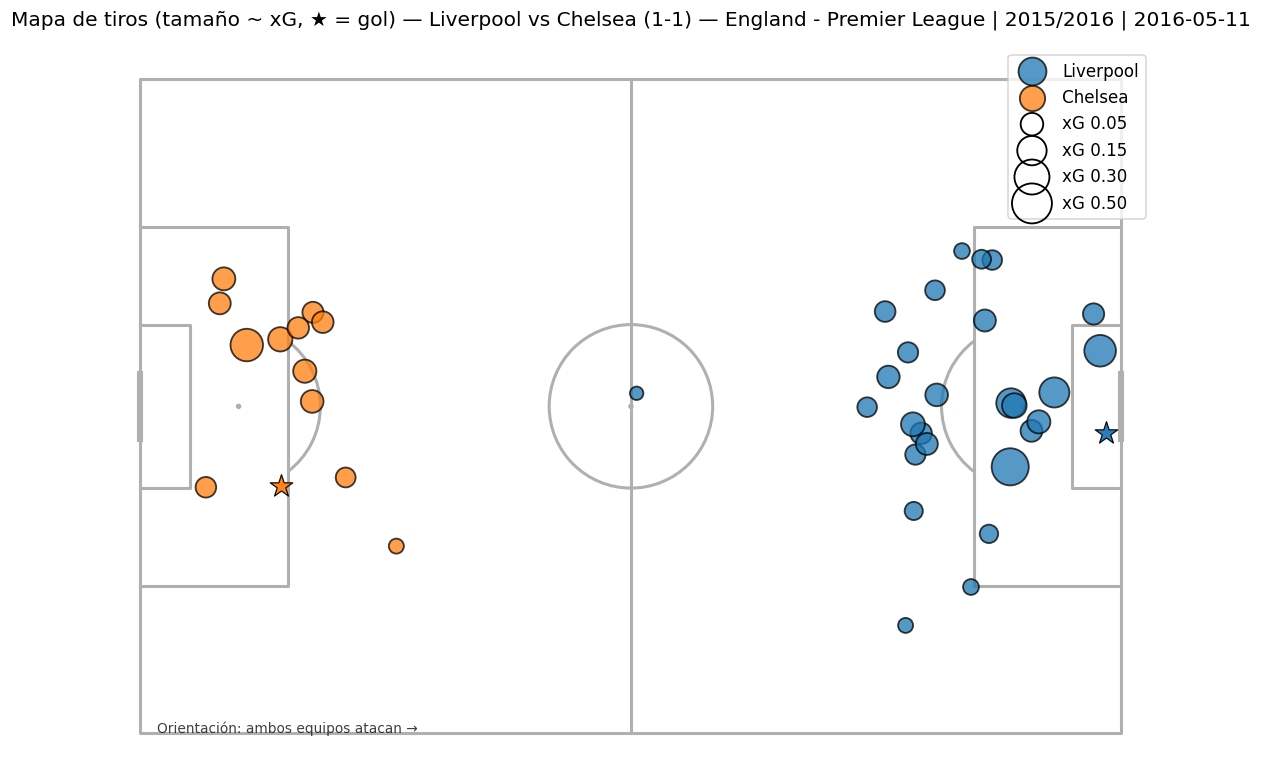

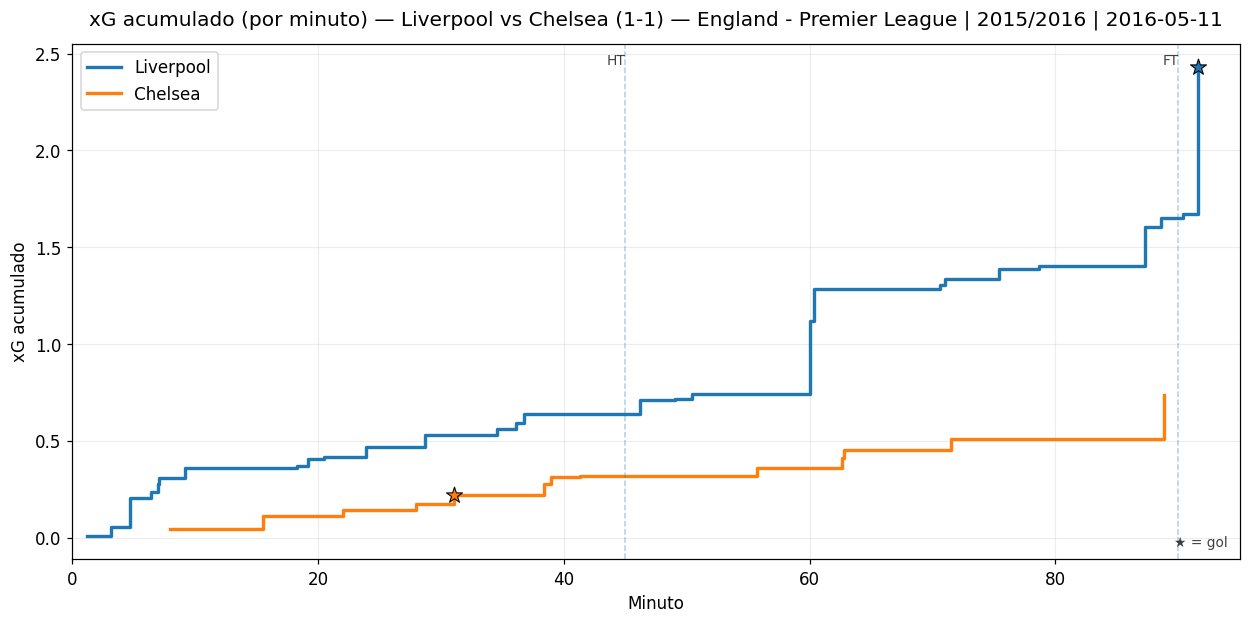

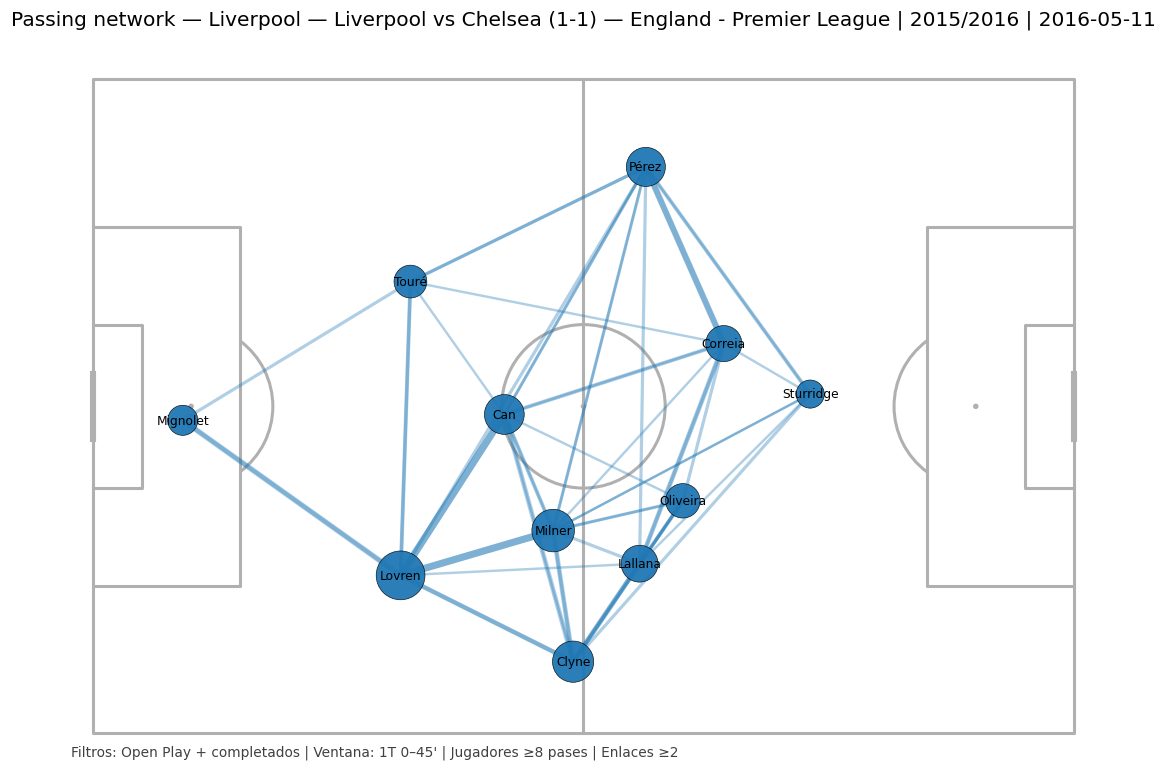

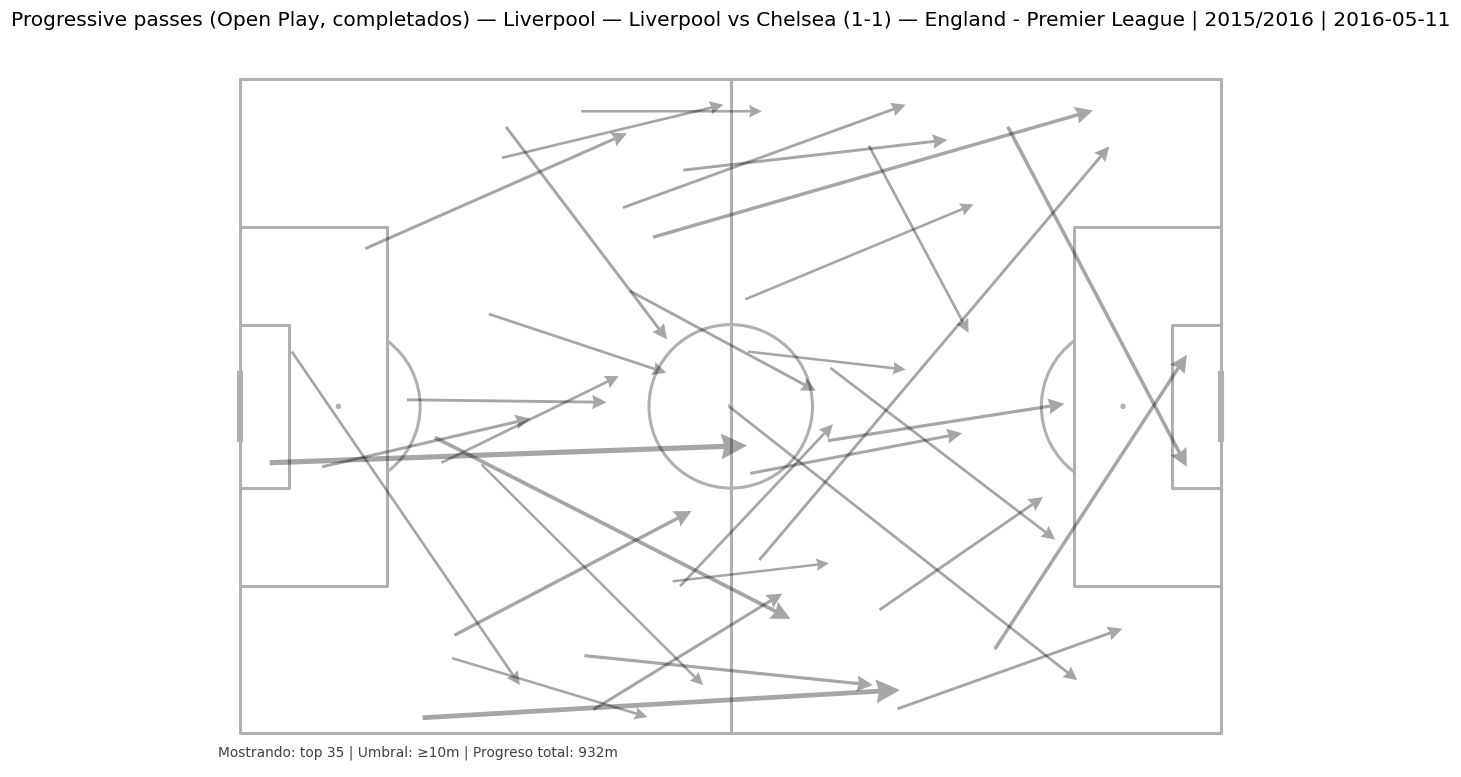

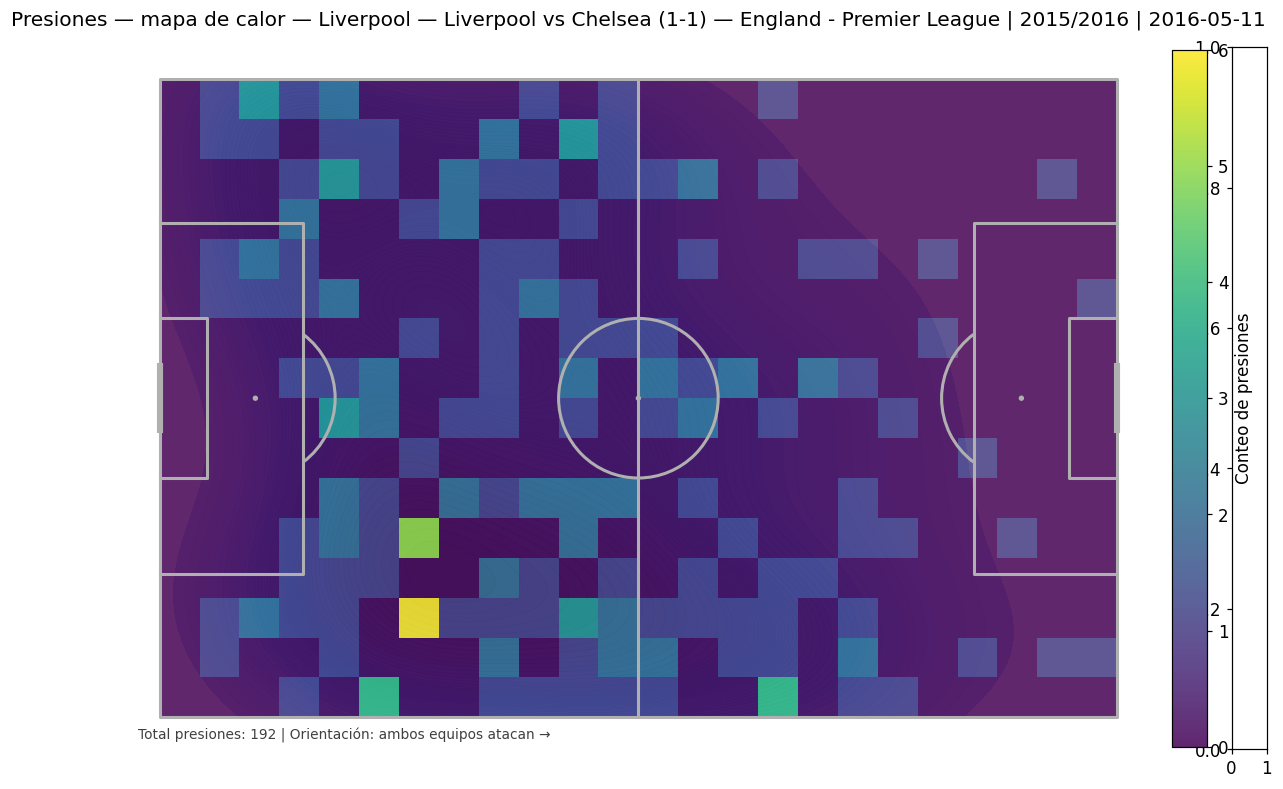

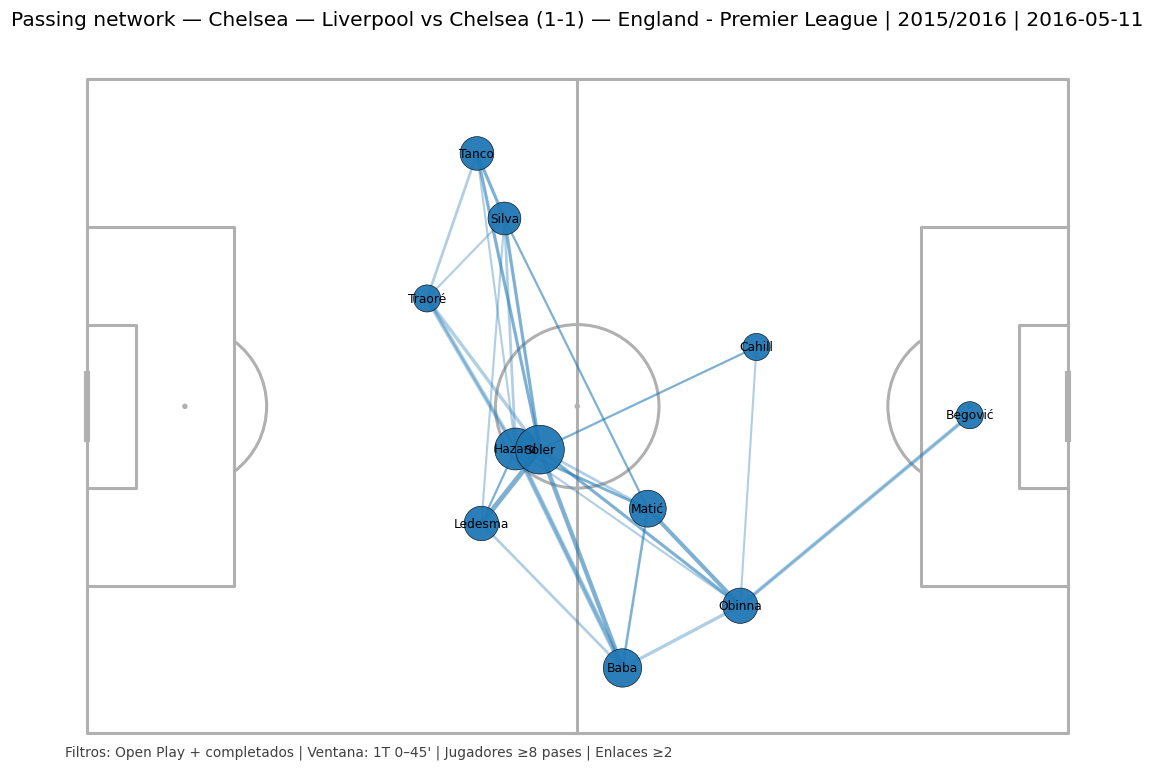

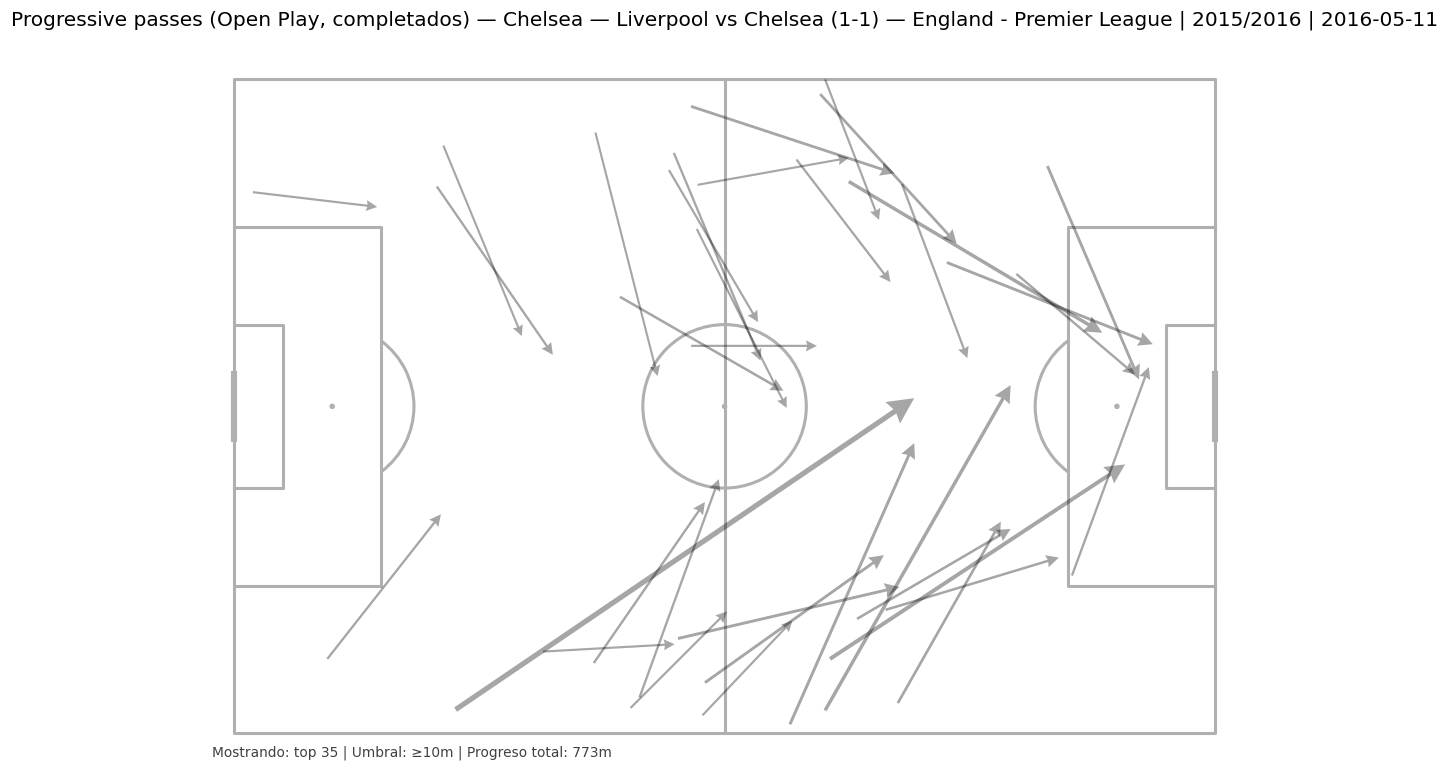

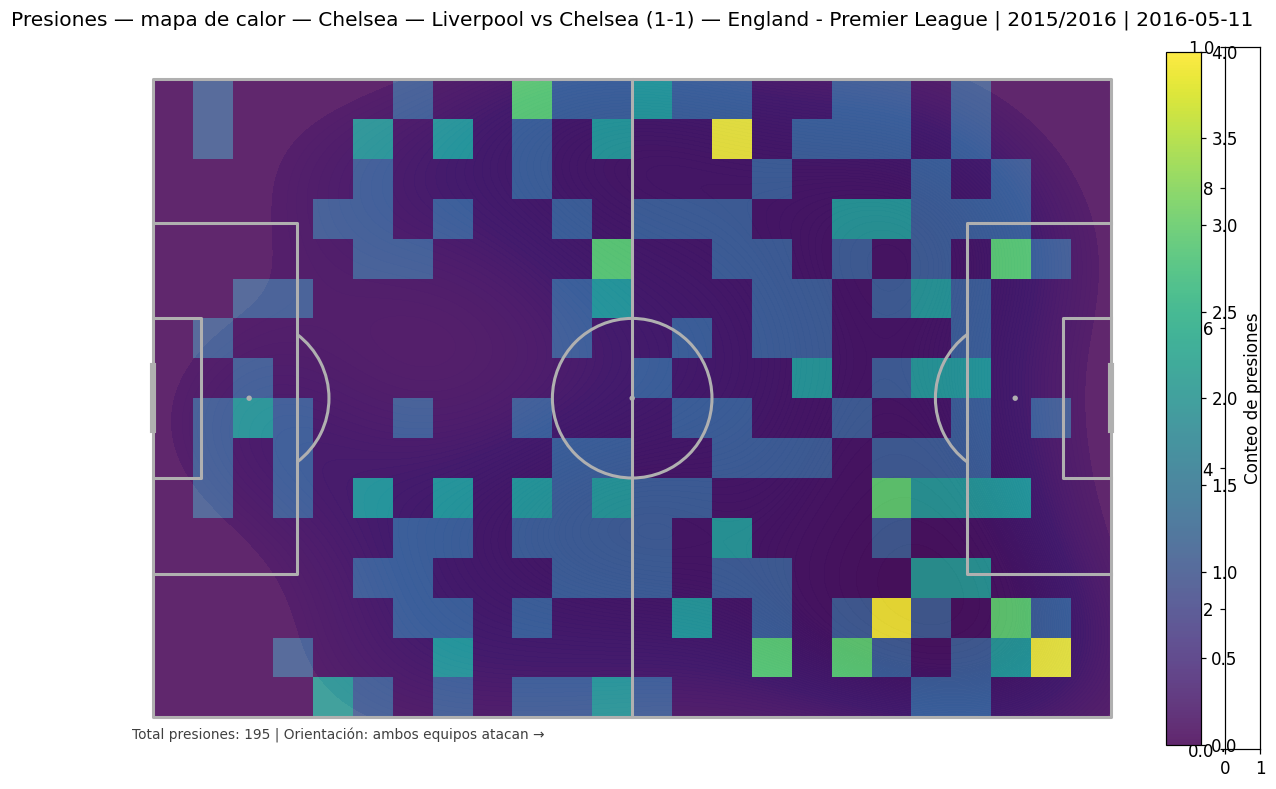

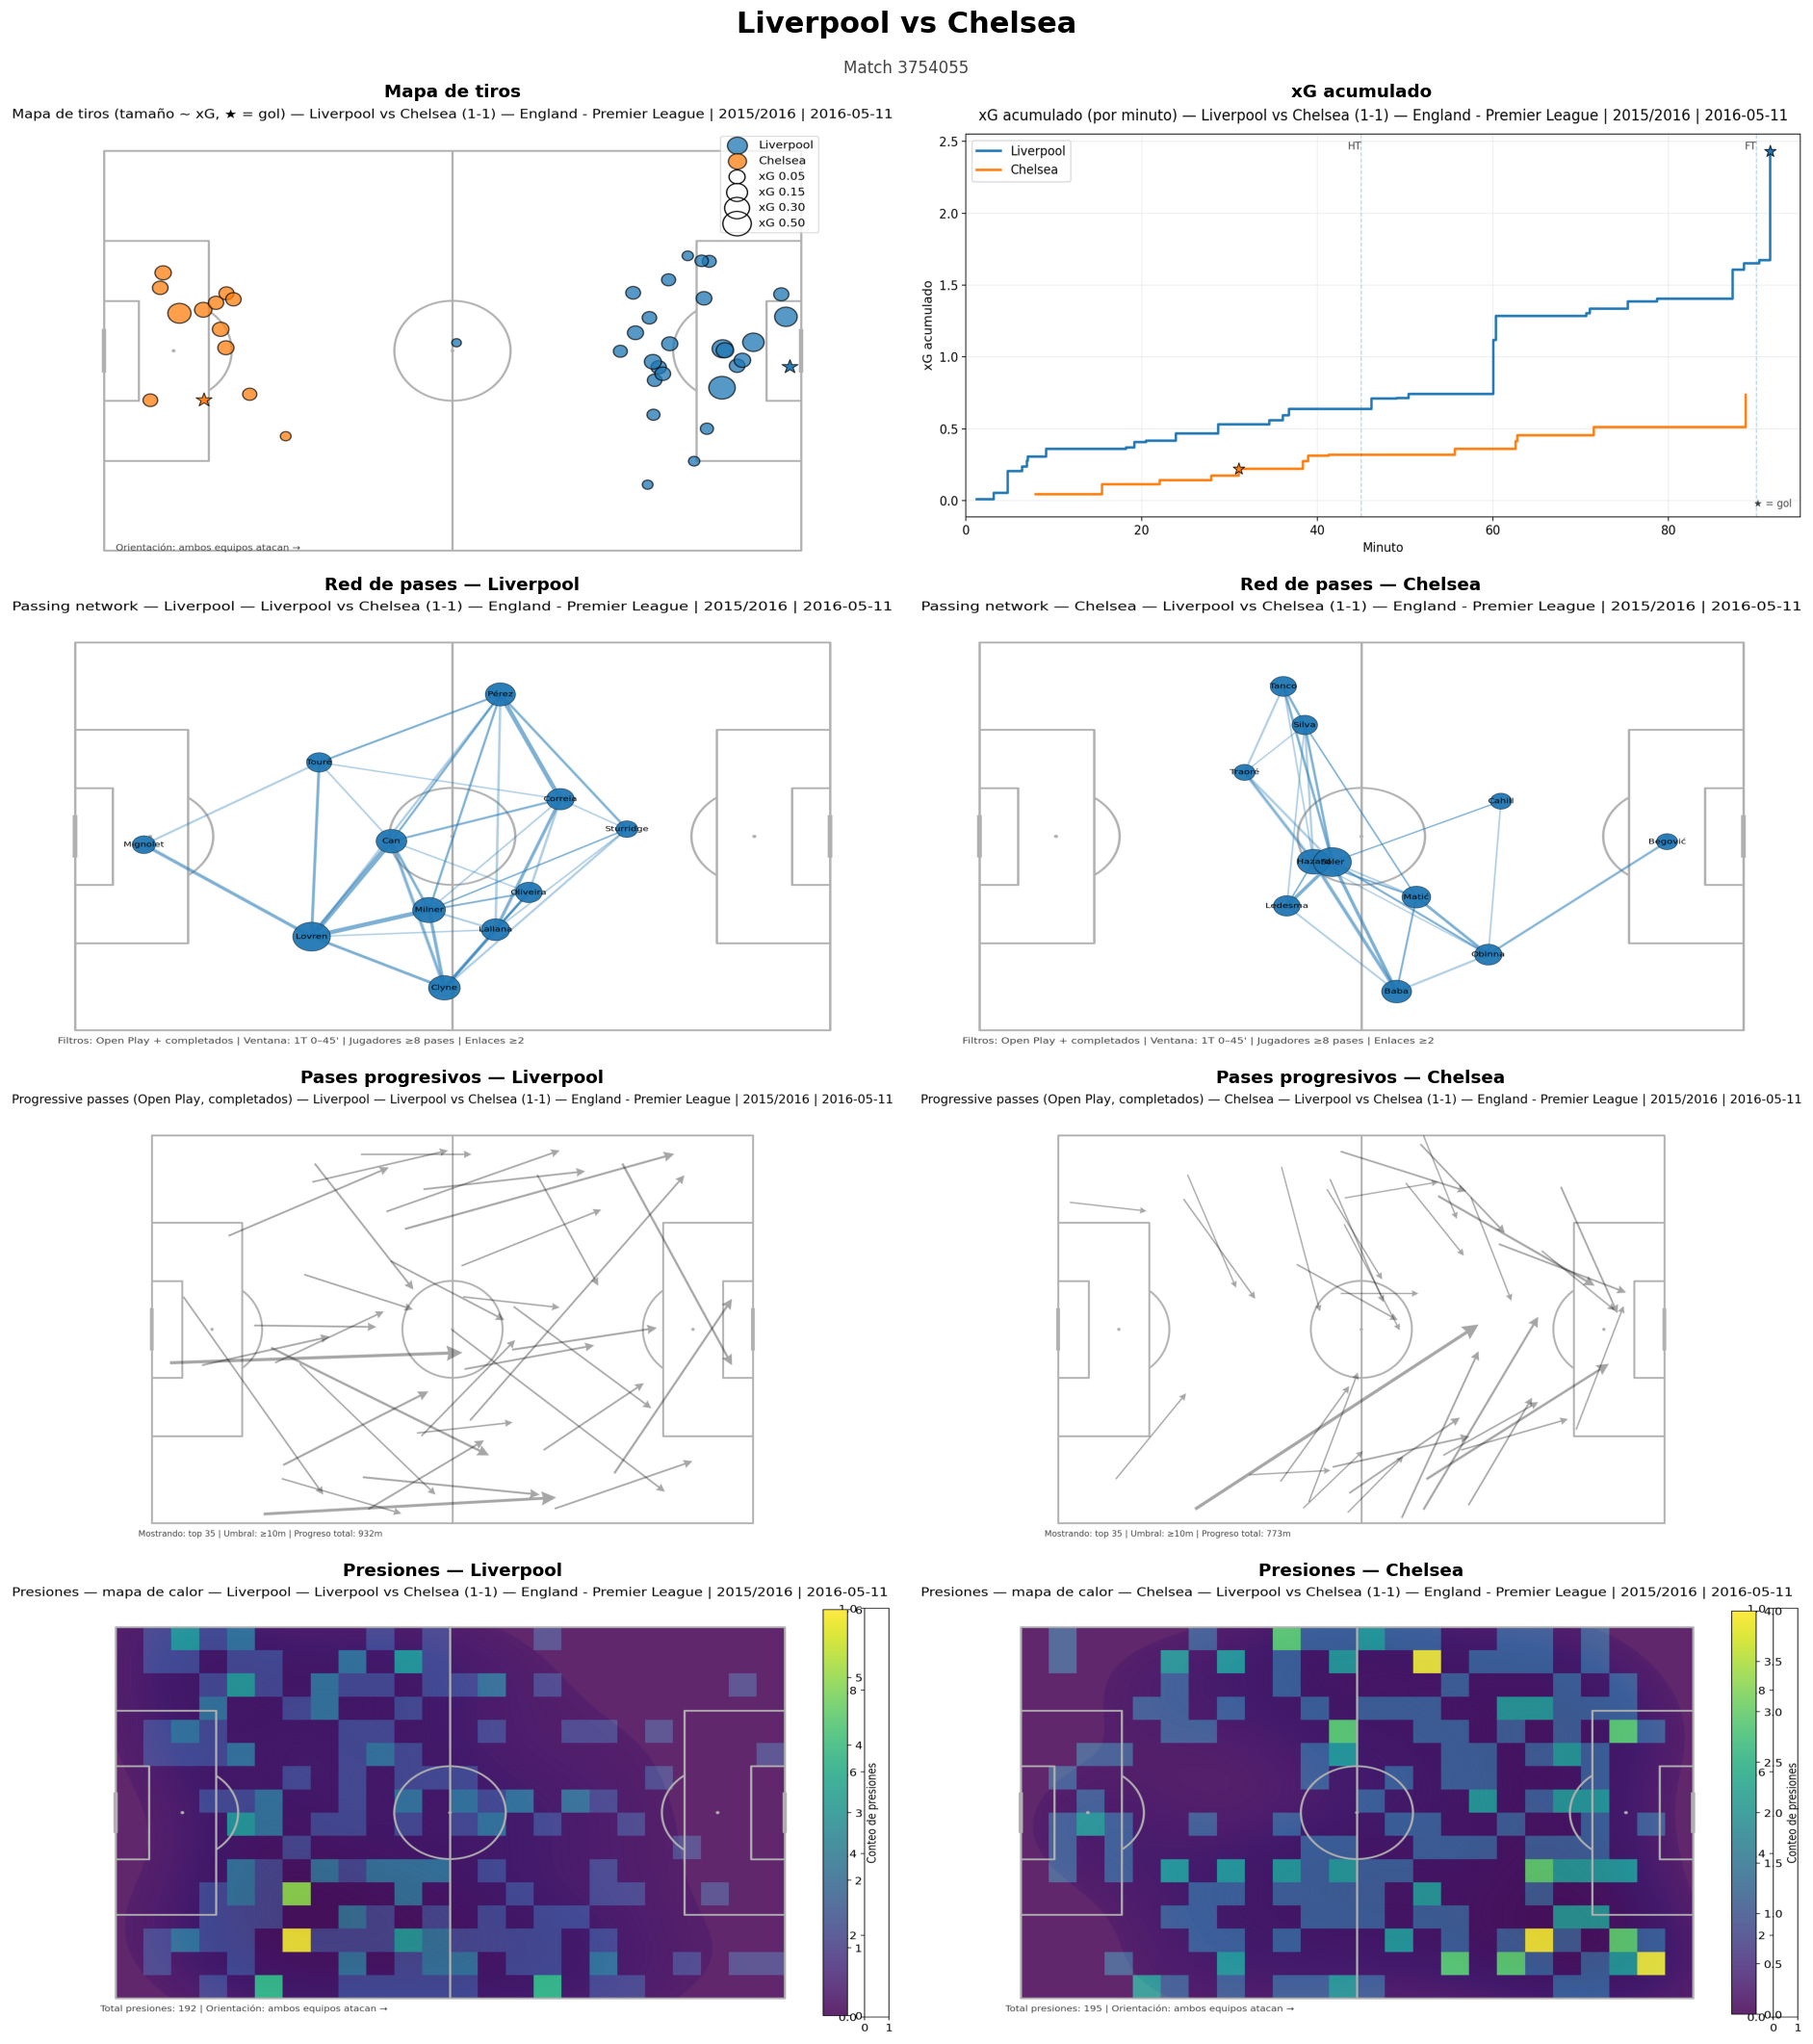

In [ ]:
# 4) Menú interactivo (flujo completo)
# Flujo: elegir competición → elegir partido → elegir qué descargar → crear carpeta → guardar → graficar

out = widgets.Output()

competitions = get_competitions()

# columnas típicas de competitions
cid_col = "competition_id" if "competition_id" in competitions.columns else "competition"
sid_col = "season_id" if "season_id" in competitions.columns else "season"
cn_col  = "competition_name" if "competition_name" in competitions.columns else "competition"
sn_col  = "season_name" if "season_name" in competitions.columns else "season"

def comp_label(row) -> str:
    cn = str(row.get(cn_col, "")).strip()
    sn = str(row.get(sn_col, "")).strip()
    cid = int(row.get(cid_col))
    sid = int(row.get(sid_col))
    return f"{cn} | {sn} (competition_id={cid}, season_id={sid})"

comps = competitions.copy()
if cn_col in comps.columns and sn_col in comps.columns:
    comps = comps.sort_values([cn_col, sn_col])

comp_options = [(comp_label(r), (int(r[cid_col]), int(r[sid_col]))) for _, r in comps.iterrows()]

dd_comp = widgets.Dropdown(options=comp_options, description="Competición:", layout=widgets.Layout(width="980px"))

dd_match = widgets.Dropdown(options=[("Selecciona una competición primero", None)], description="Partido:", layout=widgets.Layout(width="980px"), disabled=True)

html_selected = widgets.HTML(value="<b>Selección:</b> —")

cb_get_matches = widgets.Checkbox(value=True, description="Descargar MATCHES (temporada)", indent=False)
cb_get_events  = widgets.Checkbox(value=True, description="Descargar EVENTS (partido)", indent=False)
cb_get_lineups = widgets.Checkbox(value=True, description="Descargar LINEUPS (partido)", indent=False)

cb_save_csv = widgets.Checkbox(value=True, description="Guardar CSV", indent=False)
cb_save_parquet = widgets.Checkbox(value=True, description="Guardar Parquet", indent=False)
cb_save_figs = widgets.Checkbox(value=True, description="Guardar gráficas (.png)", indent=False)

btn_run = widgets.Button(description="Descargar + Generar gráficas", button_style="success", layout=widgets.Layout(width="260px"))

STATE = {"matches": None, "events": None, "lineups": None, "ctx": None, "outdir": None}

def build_match_dropdown(competition_id: int, season_id: int):
    m = get_matches(competition_id, season_id)

    midc = "match_id"
    home = "home_team_name" if "home_team_name" in m.columns else ("home_team" if "home_team" in m.columns else None)
    away = "away_team_name" if "away_team_name" in m.columns else ("away_team" if "away_team" in m.columns else None)
    mdate = "match_date" if "match_date" in m.columns else ("kick_off" if "kick_off" in m.columns else None)

    opts = []
    for _, r in m.iterrows():
        mid = int(r[midc])
        ht = str(r[home]) if home else "Home"
        at = str(r[away]) if away else "Away"
        dt = str(r[mdate]) if mdate else ""
        label = f"{ht} vs {at}"
        if dt and dt.lower() != "nan":
            label += f" — {dt}"
        label += f" (match_id={mid})"
        opts.append((label, mid))

    dd_match.options = opts if opts else [("No hay partidos", None)]
    dd_match.disabled = not bool(opts)

def update_selected_text():
    cid, sid = dd_comp.value if dd_comp.value else (None, None)
    mid = dd_match.value
    html_selected.value = f"<b>Selección:</b> competition_id={cid}, season_id={sid} | match_id={mid if mid else '—'}"

def on_comp_change(change):
    if change["name"] == "value" and change["new"] is not None:
        cid, sid = change["new"]
        dd_match.disabled = True
        dd_match.options = [("Cargando partidos…", None)]
        with out:
            clear_output()
            print("Cargando partidos de la temporada…")
        build_match_dropdown(cid, sid)
        update_selected_text()
        with out:
            print("OK ✅")

def on_match_change(change):
    if change["name"] == "value":
        update_selected_text()

dd_comp.observe(on_comp_change)
dd_match.observe(on_match_change)

cid0, sid0 = dd_comp.value
build_match_dropdown(cid0, sid0)
dd_match.disabled = False
update_selected_text()

def run_pipeline(_):
    cid, sid = dd_comp.value
    mid = dd_match.value
    if mid is None:
        with out:
            clear_output()
            print("Selecciona un partido.")
        return

    with out:
        clear_output()
        print(f"Competición: {cid} | Temporada: {sid}")
        print(f"Partido: match_id={mid}")
        print("-"*60)

    matches_df = None
    if cb_get_matches.value:
        with out:
            print("Descargando MATCHES…")
        matches_df = get_matches(cid, sid)
        STATE["matches"] = matches_df

    if matches_df is None:
        matches_df = get_matches(cid, sid)
        STATE["matches"] = matches_df

    ctx = match_context(matches_df, mid)
    STATE["ctx"] = ctx
    outdir = match_outdir(ctx)
    STATE["outdir"] = outdir

    with out:
        print(f"Carpeta creada/seleccionada: {outdir}")

    if cb_get_events.value:
        with out:
            print("Descargando EVENTS…")
        STATE["events"] = get_events(mid)

    if cb_get_lineups.value:
        with out:
            print("Descargando LINEUPS…")
        STATE["lineups"] = get_lineups(mid)

    with out:
        print("-"*60)
        print("Guardando archivos…")

    if cb_get_matches.value and STATE["matches"] is not None:
        saved = save_df(STATE["matches"], outdir, "matches", save_csv=cb_save_csv.value, save_parquet=cb_save_parquet.value)
        with out: print("matches:", {k: str(v) for k,v in saved.items()})

    if cb_get_events.value and STATE["events"] is not None:
        saved = save_df(STATE["events"], outdir, "events", save_csv=cb_save_csv.value, save_parquet=cb_save_parquet.value)
        with out: print("events:", {k: str(v) for k,v in saved.items()})

    if cb_get_lineups.value and STATE["lineups"] is not None:
        saved = save_df(STATE["lineups"], outdir, "lineups", save_csv=cb_save_csv.value, save_parquet=cb_save_parquet.value)
        with out: print("lineups:", {k: str(v) for k,v in saved.items()})

    with out:
        print("-"*60)
        print("Generando gráficas…")

    if STATE["events"] is None:
        with out:
            print("⚠️ No hay EVENTS cargados. Activa 'Descargar EVENTS' para generar gráficas.")
        return

    try:
        generate_top5(STATE["events"], STATE["matches"], mid, save_figs=cb_save_figs.value, outdir=outdir)
        with out:
            print("Listo ✅")
            if cb_save_figs.value:
                print("Gráficas guardadas dentro de la carpeta del partido.")
    except Exception as e:
        with out:
            print(f"❌ Error al generar gráficas: {e}")

btn_run.on_click(run_pipeline)

ui = widgets.VBox([
    dd_comp,
    dd_match,
    html_selected,
    widgets.HTML("<hr>"),
    widgets.HTML("<b>¿Qué quieres descargar?</b>"),
    widgets.VBox([cb_get_matches, cb_get_events, cb_get_lineups]),
    widgets.HTML("<b>Guardado</b>"),
    widgets.VBox([cb_save_csv, cb_save_parquet, cb_save_figs]),
    btn_run,
    out
])

display(ui)
